# Hate Speech Detection: a comparative study

Multiclass classification of tweets (hate speech, offensive language, or neither) on the Davidson et al. (2017) dataset, comparing Logistic Regression, SVM, a bidirectional LSTM, and a fine-tuned RoBERTa. Put `labeled_data.csv` in `../data/raw/` (see `../data/README.md`).

## 1. Setup and Imports

I rely on NLTK (the Natural Language Toolkit) for the English stopwords list and the WordNet lemmatiser. The authors of the library ask that it be cited whenever it is used, so here is the reference: Bird, S., Klein, E., & Loper, E. (2009). *Natural Language Processing with Python*. O'Reilly Media. Available at https://www.nltk.org/book/.


In [27]:
# Basic data handling and plotting libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re                           # regular expressions, used to clean text
import os                           # to create folders for saving figures
import warnings
warnings.filterwarnings('ignore')   # hide warnings so the output stays clean

# NLP tools from NLTK
import nltk
# download the small resource files NLTK needs (stopwords, lemmatiser data, tokeniser)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.corpus import stopwords          # list of common English words to drop
from nltk.stem import WordNetLemmatizer    # reduces words like "running" to "run"
from collections import Counter            # used for counting word frequencies
from wordcloud import WordCloud            # for drawing the word cloud figures

# Traditional ML (scikit-learn)
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score, roc_auc_score, roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.calibration import CalibratedClassifierCV

# Deep Learning (PyTorch and Hugging Face)
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import RobertaTokenizer, RobertaForSequenceClassification, get_linear_schedule_with_warmup
from torch.optim import AdamW

In [28]:
# Fix the random seed so that the results are reproducible every run
seed = 1
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

# Use the GPU if one is available, otherwise use the CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Create a folder where all the figures I generate will be saved
os.makedirs('figures', exist_ok=True)

Using device: cuda


## 2. Data Loading

The column I care about the most is `class`, which tells me what category the tweet belongs to:

- **0**: the tweet is hate speech
- **1**: it contains offensive language but it is not hate speech
- **2**: it is neither of the above

In [29]:
# Load the csv file
df = pd.read_csv('../data/raw/labeled_data.csv')

# The 'class' column is just numbers (0, 1, 2). Let's add a second column with a readable name to make it easier
label_map = {0: 'hate_speech', 1: 'offensive_language', 2: 'neither'}
df['label_name'] = df['class'].map(label_map)

# Let's check the dataset's size and how many tweets fall into each class
print(f"Dataset shape: {df.shape}")
print(f"\nColumn names: {df.columns.tolist()}")
print(f"\nClass distribution:")
print(df['class'].value_counts().sort_index())
print(f"\nFirst 5 rows:")
df.head()

Dataset shape: (24783, 8)

Column names: ['Unnamed: 0', 'count', 'hate_speech', 'offensive_language', 'neither', 'class', 'tweet', 'label_name']

Class distribution:
class
0     1430
1    19190
2     4163
Name: count, dtype: int64

First 5 rows:


,Unnamed: 0,count,hate_speech,offensive_language,neither,class,tweet,label_name
0,0,3,0,0,3,2,!!! RT @mayasolovely: As a woman you shouldn't...,neither
1,1,3,0,3,0,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...,offensive_language
2,2,3,0,3,0,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...,offensive_language
3,3,3,0,2,1,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...,offensive_language
4,4,6,0,6,0,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...,offensive_language


## 3. Data Cleaning

Before diving into the analysis, Let's check for irregularities in the data and clean.

So in the cell below I first check how many missing values and duplicates exist, and then I drop them if there are any.

In [30]:
# check for missing values in each column
print("Missing values per column:")
print(df.isnull().sum())

# check how many duplicate rows we have (based on the tweet text)
n_duplicates = df.duplicated(subset=['tweet']).sum()
print(f"\nNumber of duplicate tweets: {n_duplicates}")

# drop missing records.
rows_before = len(df)
df = df.dropna()

# Drop duplicated tweets, keeping only the first occurrence
df = df.drop_duplicates(subset=['tweet'], keep='first')

# Reset the index so the row numbers are clean and sequential again
df = df.reset_index(drop=True)

rows_after = len(df)
print(f"\nRows before cleaning: {rows_before}")
print(f"Rows after cleaning:  {rows_after}")
print(f"Rows removed:         {rows_before - rows_after}")


Missing values per column:
Unnamed: 0            0
count                 0
hate_speech           0
offensive_language    0
neither               0
class                 0
tweet                 0
label_name            0
dtype: int64

Number of duplicate tweets: 0

Rows before cleaning: 24783
Rows after cleaning:  24783
Rows removed:         0


## 4. Exploratory Data Analysis

Now that the data is clean, let's look at it before we start modelling.

The goal of this section is to answer a few simple questions:
1. How are the classes distributed?
2. How long are the tweets?
3. What words show up the most in each class?

### 4.1 Text Preprocessing

I save two cleaned versions of each tweet: `clean_text` (stopwords removed) for Logistic Regression and SVM, and `clean_text_full` (stopwords kept) for the LSTM.

In [31]:
# turns words into their base form
lemmatiser = WordNetLemmatizer()

# build the list of English stopwords once. The EDA cells will reuse it
stop_words = set(stopwords.words('english'))


def clean_text(text, remove_stopwords=True):
    """Take a raw tweet and return a cleaned version of it."""
    # Get rid of links first
    text = re.sub(r'http\S+|www\S+', '', text)
    # Drop @mentions like @username
    text = re.sub(r'@\w+', '', text)
    # Drop the 'RT' that appears at the start of retweets
    text = re.sub(r'RT\s*', '', text)
    # Replace the HTML '&amp;' with the word 'and'
    text = re.sub(r'&amp;', 'and', text)
    # Keep only letters and spaces (everything else is discarded)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Lowercase and remove extra whitespace at the ends
    text = text.lower().strip()

    # Split the tweet into individual words
    tokens = text.split()

    # Optionally drop stopwords (we only do this for the traditional ML models)
    if remove_stopwords:
        tokens = [w for w in tokens if w not in stop_words]

    # Lemmatise each remaining word
    tokens = [lemmatiser.lemmatize(w) for w in tokens]

    # Stitch the tokens back into a single string
    return ' '.join(tokens)


# Apply the cleaning to every tweet in the dataset.
df['clean_text'] = df['tweet'].apply(lambda x: clean_text(x))
df['clean_text_full'] = df['tweet'].apply(lambda x: clean_text(x, remove_stopwords=False))

# Show a couple of examples so we can see the "before vs after" effect
print("A few examples of the cleaning:")
for i in [0, 5, 100]:
    print(f"\nOriginal:  {df.iloc[i]['tweet'][:100]}")
    print(f"Cleaned:   {df.iloc[i]['clean_text'][:100]}")


A few examples of the cleaning:

Original:  !!! RT @mayasolovely: As a woman you shouldn't complain about cleaning up your house. &amp; as a man
Cleaned:   woman shouldnt complain cleaning house man always take trash

Original:  !!!!!!!!!!!!!!!!!!"@T_Madison_x: The shit just blows me..claim you so faithful and down for somebody
Cleaned:   shit blow meclaim faithful somebody still fucking hoe

Original:  "@ClicquotSuave: LMAOOOOOOOOOOO this nigga @Krillz_Nuh_Care http://t.co/AAnpSUjmYI" &lt;bitch want l
Cleaned:   lmaooooooooooo nigga ltbitch want like depressing shitfoh


### 4.2 Class Distribution

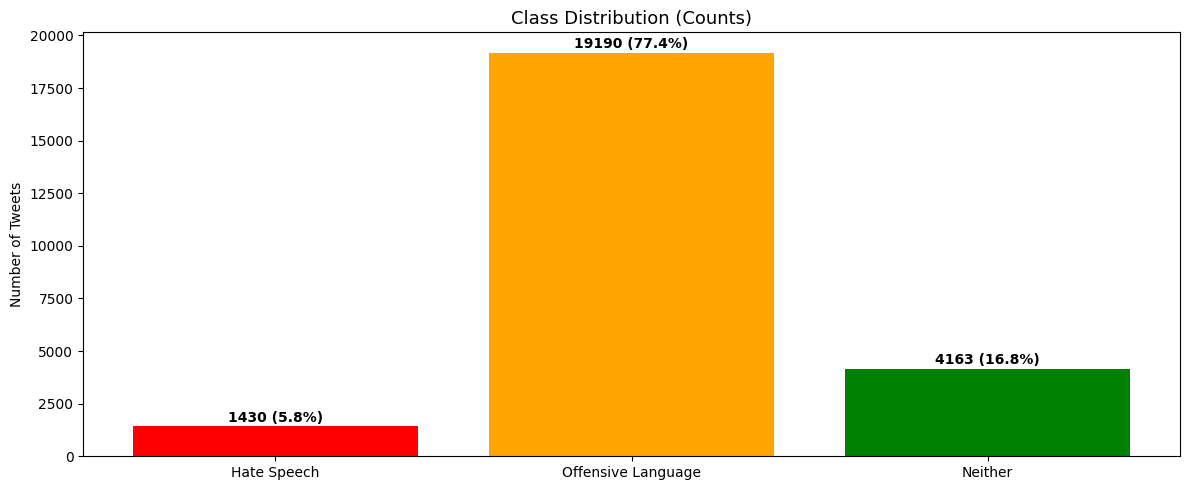


Hate speech: 1430 (5.8%)

Offensive language: 19190 (77.4%)

Neither: 4163 (16.8%)


In [32]:
plt.figure(figsize=(12, 5))

# Count how many tweets belong to each class and sort them by the class id (0,1,2)
class_counts = df['class'].value_counts().sort_index()

# Colours and readable names for the three classes
colours = ['red', 'orange', 'green']
class_labels = ['Hate Speech', 'Offensive Language', 'Neither']

# Draw a simple bar chart
plt.bar(class_labels, class_counts.values, color=colours)
plt.title('Class Distribution (Counts)', fontsize=13)
plt.ylabel('Number of Tweets')

# Add the count and percentage on top of each bar so the numbers are easy to read
for i, v in enumerate(class_counts.values):
    plt.text(i, v + 200,
             str(v) + f' ({class_counts[i]/len(df)*100:.1f}%)',
             ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('figures/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Also print the numbers for the record
print(f"\nHate speech: {class_counts[0]} ({class_counts[0]/len(df)*100:.1f}%)")
print(f"\nOffensive language: {class_counts[1]} ({class_counts[1]/len(df)*100:.1f}%)")
print(f"\nNeither: {class_counts[2]} ({class_counts[2]/len(df)*100:.1f}%)")

The dataset is really imbalanced: around 77% of the tweets are offensive language and only about 6% are actual hate speech.

### 4.3 Text Length Analysis

Another useful thing to check is how long the tweets are, both in characters and in words. This matters for the deep learning models later because I have to pick a maximum sequence length to truncate to. If I pick it too small I lose information, and if I pick it too big I waste memory on mostly empty padding. Looking at the distribution tells me what a sensible value would be.


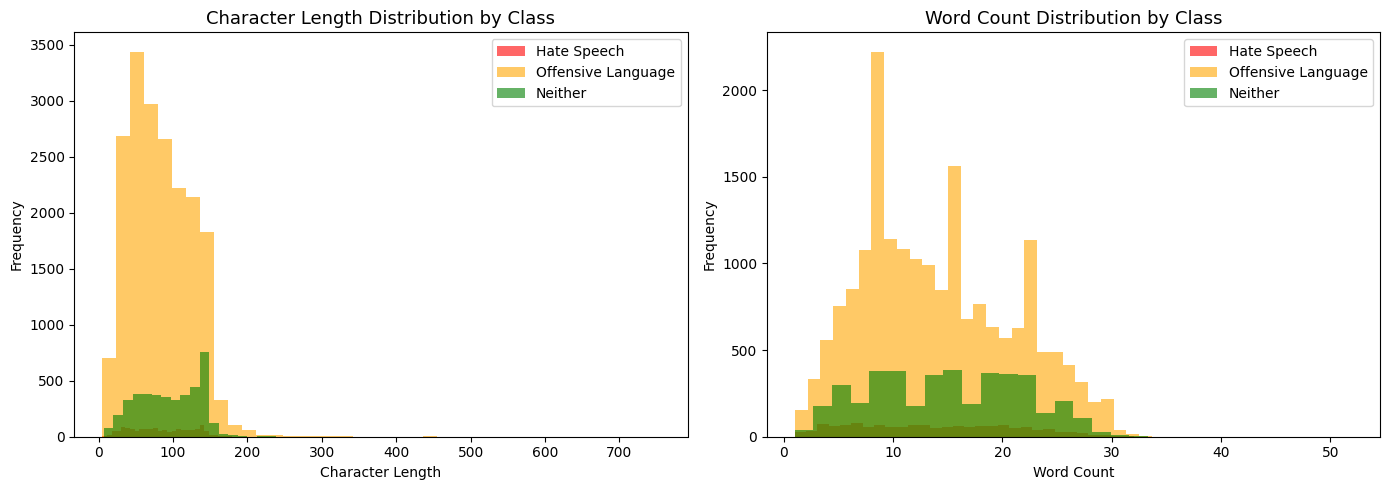

Text length statistics per class:
  Hate Speech: mean chars=85, mean words=14
  Offensive Language: mean chars=83, mean words=14
  Neither: mean chars=95, mean words=15


In [33]:
# Compute the character length and word count for every tweet
df['char_length'] = df['tweet'].apply(lambda x: len(x))
df['word_count'] = df['tweet'].apply(lambda x: len(x.split()))

# Two side-by-side histograms: one for char length, one for word count
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Draw one histogram per class on each subplot, using transparency so they overlap nicely
for cls, label, colour in zip([0, 1, 2], class_labels, colours):
    subset = df[df['class'] == cls]
    axes[0].hist(subset['char_length'], bins=40, alpha=0.6, label=label, color=colour)
    axes[1].hist(subset['word_count'],  bins=30, alpha=0.6, label=label, color=colour)

axes[0].set_title('Character Length Distribution by Class', fontsize=13)
axes[0].set_xlabel('Character Length')
axes[0].set_ylabel('Frequency')
axes[0].legend()

axes[1].set_title('Word Count Distribution by Class', fontsize=13)
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.savefig('figures/text_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Print the mean length per class so we have a quick numeric summary
print("Text length statistics per class:")
for cls, label in zip([0, 1, 2], class_labels):
    subset = df[df['class'] == cls]
    print(f"  {label}: mean chars={subset['char_length'].mean():.0f}, mean words={subset['word_count'].mean():.0f}")

### 4.4 Word Clouds

Word clouds are a quick visual way to see which words show up the most in each class

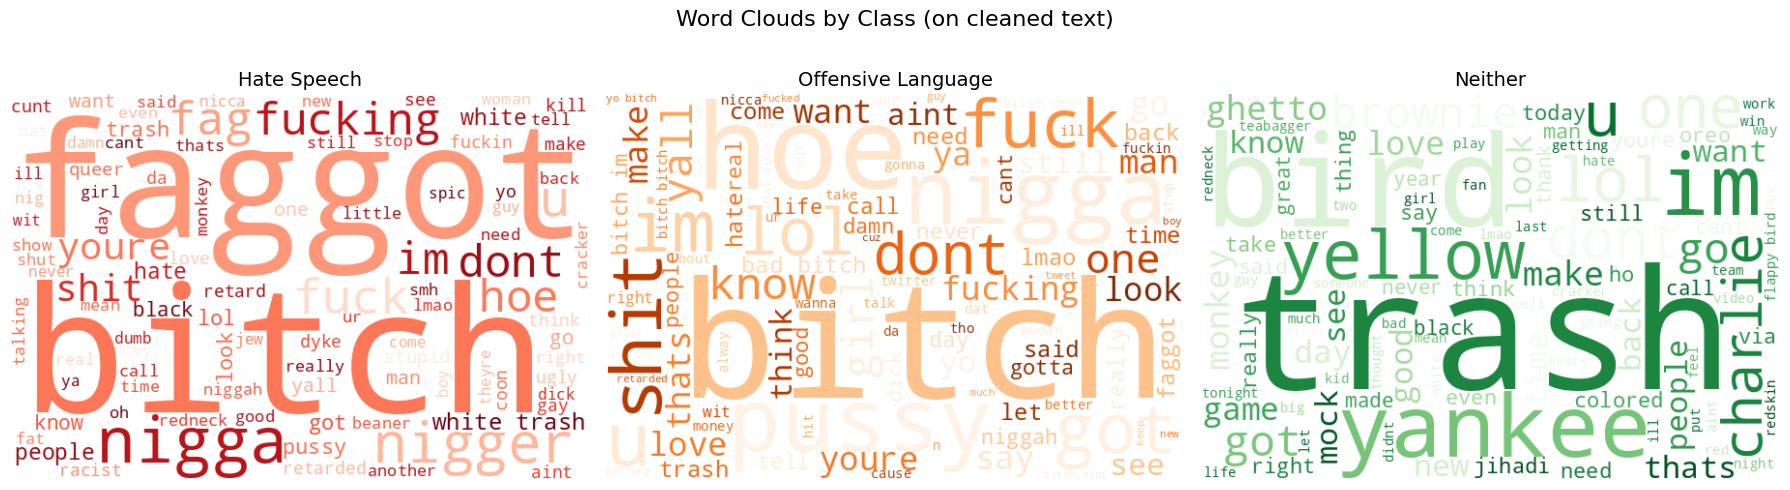

In [34]:
# Draw one word cloud per class, using the cleaned text from the preprocessing step
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (cls, label, colour) in enumerate(zip([0, 1, 2], class_labels, ['Reds', 'Oranges', 'Greens'])):
    # Join all cleaned tweets of this class into one long string
    text = ' '.join(df[df['class'] == cls]['clean_text'].values)

    # Build the word cloud (stopwords are already gone since we used the cleaned text)
    wc = WordCloud(width=600, height=400, max_words=100, background_color='white', colormap=colour).generate(text)

    axes[idx].imshow(wc, interpolation='bilinear')
    axes[idx].set_title(label, fontsize=14)
    axes[idx].axis('off')  # no axes on an image

plt.suptitle('Word Clouds by Class (on cleaned text)', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('figures/word_clouds.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.5 Most Common Words per Class

Knowing the most common words per class makes it much easier to spot which words are strongly associated with hate speech versus offensive language versus neither.

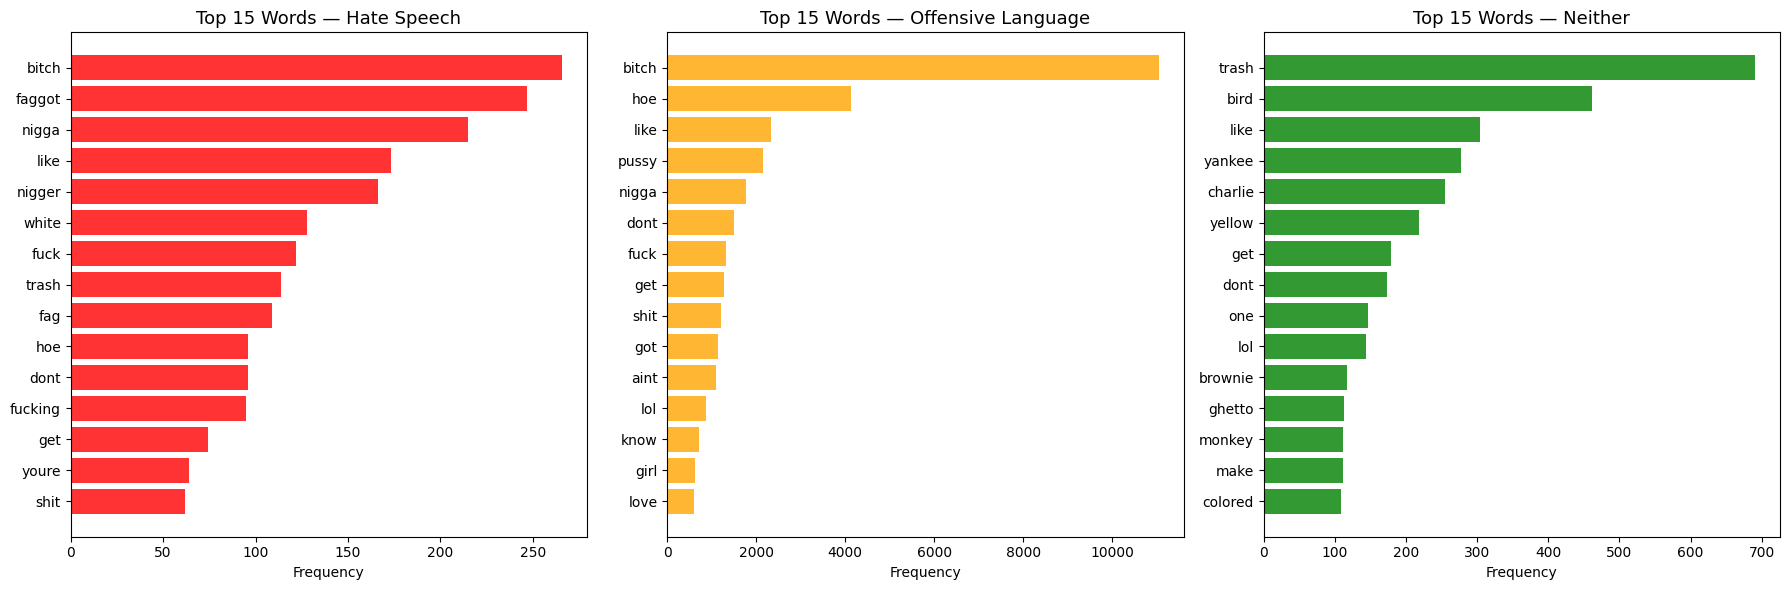

In [35]:
def get_top_words(texts, n=15):
    """Return the n most common words from a list of cleaned texts."""
    # Join all texts together and split into individual words
    words = ' '.join(texts).lower().split()
    # Keep only words longer than 2 characters (to skip leftovers like 'rt', 'im', etc.)
    words = [w for w in words if len(w) > 2]
    # Count the words and return the top n
    return Counter(words).most_common(n)


# One horizontal bar chart per class
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, (cls, label, colour) in enumerate(zip([0, 1, 2], class_labels, colours)):
    # Get the top 15 words for this class, using the already cleaned text
    top = get_top_words(df[df['class'] == cls]['clean_text'].values)
    words, counts = zip(*top)

    axes[idx].barh(range(len(words)), counts, color=colour, alpha=0.8)
    axes[idx].set_yticks(range(len(words)))
    axes[idx].set_yticklabels(words)
    axes[idx].invert_yaxis()  # so the most frequent word ends up at the top
    axes[idx].set_title(f'Top 15 Words — {label}', fontsize=13)
    axes[idx].set_xlabel('Frequency')

plt.tight_layout()
plt.savefig('figures/top_words.png', bbox_inches='tight')
plt.show()

## 5. Train / Test Split

We will have 80% of the tweets for training and leave 20% aside for testing.

Let's create three parallel splits:

1. `x_train` / `x_test`. Cleaned text with stopwords removed (for Logistic Regression and SVM).
2. `x_train_full` / `x_test_full`. Cleaned text with stopwords kept (for the LSTM).
3. `x_train_raw` / `x_test_raw`. The original raw tweets (for RoBERTa, because its own tokeniser prefers the raw text).


In [36]:
# Inputs and targets for the three versions of the text
x       = df['clean_text'].values          # cleaned, stopwords removed (traditional ML)
x_full  = df['clean_text_full'].values     # cleaned, stopwords kept    (LSTM)
y       = df['class'].values               # class labels (0, 1, 2)

# Main split used by the traditional ML models
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=seed, stratify=y)

# Same split indices but on the 'with stopwords' version for the LSTM.
x_train_full, x_test_full, _, _ = train_test_split(x_full, y, test_size=0.2, random_state=seed, stratify=y)

# Same split again on the raw tweets for the RoBERTa tokeniser
x_train_raw, x_test_raw, _, _ = train_test_split(df['tweet'].values, y, test_size=0.2, random_state=seed, stratify=y)

print(f"Training set: {len(x_train)} samples")
print(f"Test set: {len(x_test)} samples")

Training set: 19826 samples
Test set: 4957 samples


## 5.1 Handling Class Imbalance with Oversampling

I only oversample the training set. The test set stays untouched. If I oversample the test set as well, I would be inflating my numbers with duplicated tweets and my evaluation would stop being meaningful.

I oversample the text itself before TF-IDF or any tokenisation. That way all four models see the same rebalanced training set.

In [37]:
# Count how many tweets we have per class in the training set right now.
# np.bincount returns an array where index i holds the count of class i.
train_counts_before = np.bincount(y_train)
majority_count = train_counts_before.max()

print("Training counts BEFORE oversampling:")
for cls, c in enumerate(train_counts_before):
    print(f"  Class {cls} ({label_map[cls]:<18}): {c}")

# We want every class to end up with `majority_count` samples. For the majority class we keep all its original indices.
# For each minority class we keep the originals and then add extra rows, sampled with replacement, until we reach majority_count.
rng = np.random.default_rng(seed)
oversampled_indices = []

for cls in np.unique(y_train):
    cls_indices = np.where(y_train == cls)[0]
    if len(cls_indices) == majority_count:
        # Majority class: nothing to add, just keep every original row.
        oversampled_indices.append(cls_indices)
    else:
        # Minority class: keep originals + draw extras with replacement
        n_extra = majority_count - len(cls_indices)
        extras = rng.choice(cls_indices, size=n_extra, replace=True)
        oversampled_indices.append(np.concatenate([cls_indices, extras]))

# Stack all class indices into one array and shuffle so classes are interleaved
oversampled_indices = np.concatenate(oversampled_indices)
rng.shuffle(oversampled_indices)

# Apply the same indices to every parallel version of the training text.
x_train = x_train[oversampled_indices]
x_train_full = x_train_full[oversampled_indices]
x_train_raw = x_train_raw[oversampled_indices]
y_train = y_train[oversampled_indices]

train_counts_after = np.bincount(y_train)
print("\nTraining counts after oversampling:")
for cls, c in enumerate(train_counts_after):
    print(f"  Class {cls} ({label_map[cls]:<18}): {c}")
print(f"\nNew training set size: {len(y_train)}")

Training counts BEFORE oversampling:
  Class 0 (hate_speech       ): 1144
  Class 1 (offensive_language): 15352
  Class 2 (neither           ): 3330

Training counts after oversampling:
  Class 0 (hate_speech       ): 15352
  Class 1 (offensive_language): 15352
  Class 2 (neither           ): 15352

New training set size: 46056


Before and after the oversampling, I want to see the change with my own eyes. The figure below puts the two distributions side by side on the same figure: one axis for the original training counts, one axis for the oversampled ones. On the left the bars are very uneven; on the right they should all be the same height.

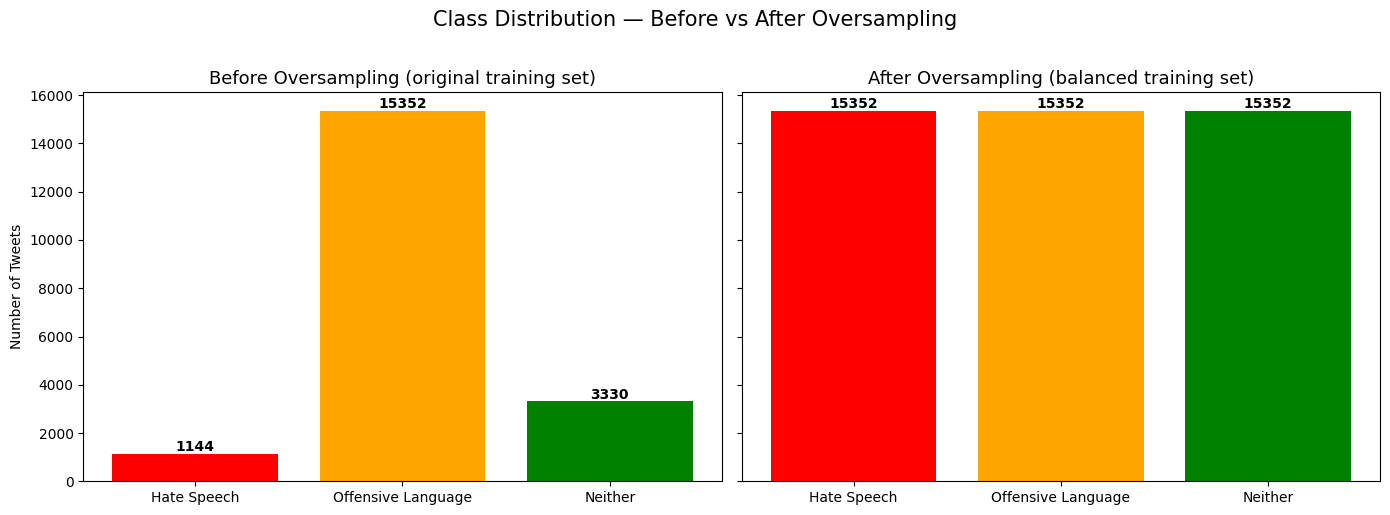

In [38]:
# Compare the class distribution before and after oversampling
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Before oversampling
bars_before = axes[0].bar(class_labels, train_counts_before, color=colours)
axes[0].set_title('Before Oversampling (original training set)', fontsize=13)
axes[0].set_ylabel('Number of Tweets')
for bar, val in zip(bars_before, train_counts_before):
    axes[0].text(bar.get_x() + bar.get_width() / 2, val + 100,
                 f'{val}', ha='center', fontweight='bold')

# After oversampling
bars_after = axes[1].bar(class_labels, train_counts_after, color=colours)
axes[1].set_title('After Oversampling (balanced training set)', fontsize=13)
for bar, val in zip(bars_after, train_counts_after):
    axes[1].text(bar.get_x() + bar.get_width() / 2, val + 100,
                 f'{val}', ha='center', fontweight='bold')

plt.suptitle('Class Distribution — Before vs After Oversampling', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('figures/oversampling_before_after.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Feature Extraction: TF-IDF

TF-IDF (Term Frequency–Inverse Document Frequency) is a common way to turn each tweet into a numerical vector.

In [39]:
# Configure the TF-IDF vectoriser
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 2), min_df=2, max_df=0.95, sublinear_tf=True)

# Fit on the training data and transform it at the same time
x_train_tfidf = tfidf.fit_transform(x_train)

# Only transform the test data. we must not fit on it
x_test_tfidf = tfidf.transform(x_test)

print(f"TF-IDF matrix shape: {x_train_tfidf.shape}")
print(f"Vocabulary size: {len(tfidf.vocabulary_)}")

TF-IDF matrix shape: (46056, 10000)
Vocabulary size: 10000


## 7. Traditional ML Model 1: Logistic Regression

### 7.1 Hyperparameter Tuning

Before I train the final model I want to talk through what I am actually doing here, because picking hyperparameters by hand has always felt a bit arbitrary to me. So in this section I try to be explicit about why I am running a grid search and what each piece is doing.

For Logistic Regression the two hyperparameters that matter the most are:

- `C`: the inverse of the regularisation strength. A small `C` means strong regularisation (the model is kept simple, which can help with generalisation but can also underfit). A large `C` means weak regularisation (the model fits the training data more tightly, but risks overfitting). I try a spread of values on a log scale: `0.01, 0.1, 1, 10`.
  
- `solver`: the optimisation algorithm scikit-learn uses to actually minimise the loss. `lbfgs` is a quasi-Newton method that tends to be fast and accurate on small/medium problems. `saga` scales better to larger sparse data (like our TF-IDF matrix). I include both so the search can pick whichever converges to a better solution on our data.

Instead of trying one combination, guessing, then trying another, a grid search just enumerates every `(C, solver)` pair automatically and trains a model for each.

In [40]:
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['lbfgs', 'saga'],
    'max_iter': [1000] # plenty of iterations so the solver has time to converge
}

# Define the base model
lr_base = LogisticRegression(random_state=seed)

# StratifiedKFold keeps the class proportions inside each fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

# For every (C, solver) pair: train on 4 folds, score on the 5th, rotate, average macro F1
# n_jobs=-1 uses every CPU core and verbose=1 prints a small progress log
grid_lr = GridSearchCV(lr_base, param_grid_lr, cv=cv, scoring='f1_macro', n_jobs=-1, verbose=1)
grid_lr.fit(x_train_tfidf, y_train)

print(f"\nBest parameters: {grid_lr.best_params_}")
print(f"Best CV Macro F1: {grid_lr.best_score_:.4f}")

Fitting 5 folds for each of 8 candidates, totalling 40 fits

Best parameters: {'C': 10, 'max_iter': 1000, 'solver': 'saga'}
Best CV Macro F1: 0.9674


### 7.2 Evaluation

Once the best hyperparameters are found, I take the best model from the grid search and evaluate it on the test set.

Logistic Regression classification report:
                    precision    recall  f1-score   support

       Hate Speech     0.4068    0.3741    0.3898       286
Offensive Language     0.9436    0.9237    0.9335      3838
           Neither     0.7983    0.8980    0.8452       833

          accuracy                         0.8876      4957
         macro avg     0.7162    0.7319    0.7228      4957
      weighted avg     0.8882    0.8876    0.8873      4957

Accuracy:  0.8876
Macro F1:  0.7228


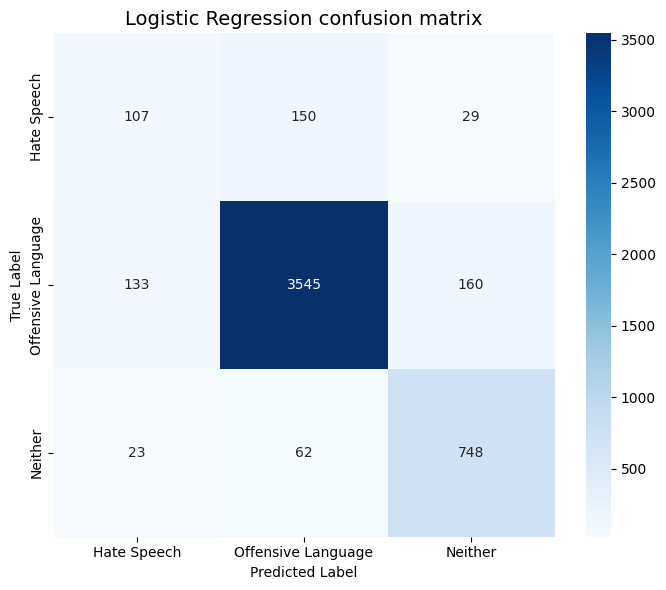

In [41]:
# Take the best model found by grid search
lr_model = grid_lr.best_estimator_

# Make predictions on the test set
y_pred_lr = lr_model.predict(x_test_tfidf)

# Compute accuracy and macro F1
lr_acc = accuracy_score(y_test, y_pred_lr)
lr_f1  = f1_score(y_test, y_pred_lr, average='macro')

print("Logistic Regression classification report:")
print(classification_report(y_test, y_pred_lr, target_names=class_labels, digits=4))
print(f"Accuracy:  {lr_acc:.4f}")
print(f"Macro F1:  {lr_f1:.4f}")

# Confusion matrix: rows = true label, columns = predicted label
cm_lr = confusion_matrix(y_test, y_pred_lr)
fig, ax = plt.subplots(figsize=(7, 6))

sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels, ax=ax)
ax.set_title('Logistic Regression confusion matrix', fontsize=14)
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('figures/cm_logistic_regression.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Traditional ML Model 2: Support Vector Machine (SVM)

The second traditional model I try is a linear SVM. The intuition behind an SVM is to find the hyperplane that separates the classes with the widest possible margin — the wider the margin, the more confident the model is. For a linear SVM, training means solving.

### 8.1 Hyperparameter Tuning (same idea)

In [42]:
param_grid_svm = {
    'C': [0.01, 0.1, 1, 10], # same C range as Logistic Regression
    'loss': ['hinge', 'squared_hinge'], # two variants of the SVM loss
    'max_iter': [5000] # LinearSVC can be slow to converge, give it room
}

# Base SVM. dual=True is the right choice when #features > #samples, which is our case after TF-IDF.
svm_base = LinearSVC(random_state=seed, dual=True)

grid_svm = GridSearchCV(svm_base, param_grid_svm, cv=cv, scoring='f1_macro', n_jobs=-1, verbose=1)
grid_svm.fit(x_train_tfidf, y_train)

print(f"\nBest parameters: {grid_svm.best_params_}")
print(f"Best CV Macro F1: {grid_svm.best_score_:.4f}")

Fitting 5 folds for each of 8 candidates, totalling 40 fits

Best parameters: {'C': 10, 'loss': 'hinge', 'max_iter': 5000}
Best CV Macro F1: 0.9691


### 8.2 Evaluation

`LinearSVC` on its own only outputs a hard class prediction. To also get probabilities (which I'll need later for the ROC curves), I wrap the best SVM in `CalibratedClassifierCV` before evaluating on the test set.


SVM classification report:
                    precision    recall  f1-score   support

       Hate Speech     0.4161    0.2168    0.2851       286
Offensive Language     0.9178    0.9429    0.9302      3838
           Neither     0.8000    0.8307    0.8151       833

          accuracy                         0.8822      4957
         macro avg     0.7113    0.6635    0.6768      4957
      weighted avg     0.8691    0.8822    0.8736      4957

Accuracy:  0.8822
Macro F1:  0.6768


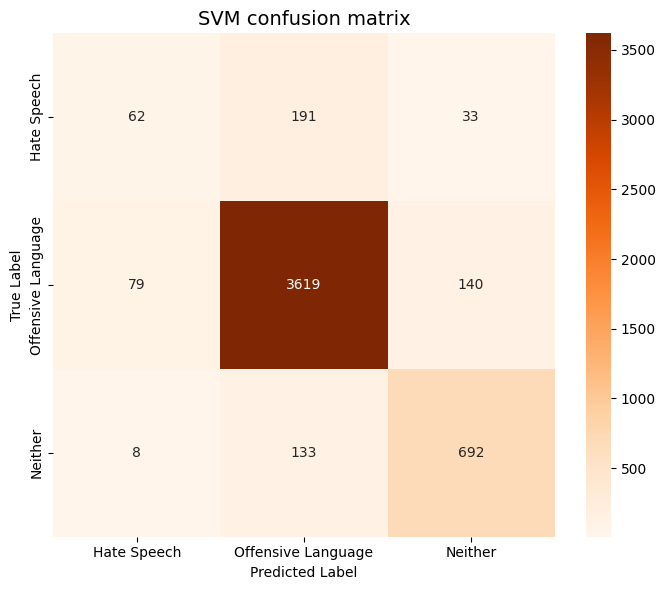

In [43]:
# Wrap the best SVM in a calibrator so we also get probability estimates
svm_calibrated = CalibratedClassifierCV(grid_svm.best_estimator_, cv=5)
svm_calibrated.fit(x_train_tfidf, y_train)

# Predict on the test set
y_pred_svm = svm_calibrated.predict(x_test_tfidf)

# Evaluate
svm_acc = accuracy_score(y_test, y_pred_svm)
svm_f1  = f1_score(y_test, y_pred_svm, average='macro')

print("SVM classification report:")
print(classification_report(y_test, y_pred_svm, target_names=class_labels, digits=4))
print(f"Accuracy:  {svm_acc:.4f}")
print(f"Macro F1:  {svm_f1:.4f}")

# Confusion matrix
cm_svm = confusion_matrix(y_test, y_pred_svm)
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=class_labels, yticklabels=class_labels, ax=ax)
ax.set_title('SVM confusion matrix', fontsize=14)
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('figures/cm_svm.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Deep Learning Model 1: LSTM

### 9.1 Data Preparation for the LSTM

In the following cell we do three things:

1. Build a vocabulary from the training data, keeping only the most common 15,000 words. Every other word becomes a special `<UNK>` (unknown) token.
2. Convert every tweet into a list of integers using that vocabulary.
3. Pad every sequence to the same length (100 tokens) so PyTorch can batch them together. Tweets longer than 100 tokens are cut off, tweets shorter than 100 are padded with zeros.


In [44]:
def build_vocab(texts, max_vocab=15000):
    """Build a word -> integer mapping from the training texts."""
    word_counts = Counter()
    for text in texts:
        word_counts.update(text.split())

    # Keep the top (max_vocab - 2) words; we reserve id 0 for <PAD> and id 1 for <UNK>
    most_common = word_counts.most_common(max_vocab - 2)

    vocab = {'<PAD>': 0, '<UNK>': 1}
    for word, _ in most_common:
        vocab[word] = len(vocab)
    return vocab


def encode_texts(texts, vocab, max_len=100):
    """Turn a list of texts into a numpy array of padded integer sequences."""
    encoded = []
    for text in texts:
        tokens = text.split()
        # Map each word to its id; unknown words get id 1 (<UNK>)
        ids = [vocab.get(w, 1) for w in tokens[:max_len]]
        # Pad with zeros at the end until the sequence reaches max_len
        ids = ids + [0] * (max_len - len(ids))
        encoded.append(ids)
    return np.array(encoded)


# Settings for the LSTM input
MAX_LEN   = 100        # each tweet is padded/cropped to 100 tokens
MAX_VOCAB = 15000      # keep the top 15k most common words

# Build the vocabulary ONLY on the training set, to avoid info leakage from the test set
vocab = build_vocab(x_train_full, max_vocab=MAX_VOCAB)

# Convert the training and test tweets into integer sequences
x_train_seq = encode_texts(x_train_full, vocab, max_len=MAX_LEN)
x_test_seq  = encode_texts(x_test_full,  vocab, max_len=MAX_LEN)

print(f"Vocabulary size: {len(vocab)}")
print(f"Training sequences shape: {x_train_seq.shape}")
print(f"Test sequences shape:     {x_test_seq.shape}")

Vocabulary size: 15000
Training sequences shape: (46056, 100)
Test sequences shape:     (4957, 100)


### 9.2 LSTM Model Definition

Here I define two things. First, a small `TweetDataset` class that wraps our numpy arrays so PyTorch can easily iterate over them in batches. Second, the `LSTMClassifier` itself. Its architecture is:

- An **embedding layer** that turns each word id into a dense 128-dim vector.
- A **bidirectional LSTM** with 2 stacked layers. Bidirectional means it reads the sequence both left-to-right and right-to-left, which usually helps on short texts.
- A **dropout** layer for regularisation (prevents overfitting).
- Two **fully connected layers** that map the LSTM's final hidden state to the 3 class logits.


In [45]:
class TweetDataset(Dataset):
    """Thin wrapper so PyTorch can iterate over our numpy arrays in batches."""
    def __init__(self, sequences, labels):
        # LongTensor because embedding layers expect integer (long) indices
        self.sequences = torch.LongTensor(sequences)
        self.labels = torch.LongTensor(labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.sequences[idx], self.labels[idx]


class LSTMClassifier(nn.Module):
    """Bidirectional LSTM classifier with a small feed-forward head on top."""

    def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim, n_layers=2, dropout=0.3):
        super().__init__()

        # Each word id -> dense vector of size embed_dim. padding_idx=0 keeps <PAD> at zero.
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        # Stacked bidirectional LSTM. batch_first=True -> input shape (batch, seq_len, features).
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=n_layers, batch_first=True, dropout=dropout, bidirectional=True)

        self.dropout = nn.Dropout(dropout)

        # hidden_dim*2 because the LSTM is bidirectional so its output is twice as wide
        self.fc1 = nn.Linear(hidden_dim * 2, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        # one row per tweet filled with word ids
        embedded = self.embedding(x)  # (batch, seq_len, embed_dim)
        _, (hidden, _) = self.lstm(embedded)

        # hidden shape is (n_layers*2, batch, hidden_dim). The last two rows are the
        # final forward and backward hidden states — concatenate them for the classifier.
        hidden_cat = torch.cat((hidden[-2], hidden[-1]), dim=1)

        out = self.dropout(hidden_cat)
        out = self.relu(self.fc1(out))
        out = self.dropout(out)
        out = self.fc2(out)   # logits for the 3 classes
        return out


print("LSTM architecture defined.")
print("Architecture: Embedding -> Bidirectional LSTM (2 layers) -> Dropout -> FC -> ReLU -> FC")

LSTM architecture defined.
Architecture: Embedding -> Bidirectional LSTM (2 layers) -> Dropout -> FC -> ReLU -> FC


### 9.3 Training the LSTM

In [46]:
# Hyperparameters
EMBED_DIM     = 128
HIDDEN_DIM    = 128
N_LAYERS      = 2
DROPOUT       = 0.3
BATCH_SIZE    = 64
EPOCHS        = 20
LEARNING_RATE = 0.001

# DataLoaders
train_dataset = TweetDataset(x_train_seq, y_train)
test_dataset  = TweetDataset(x_test_seq,  y_test)
train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader   = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

# Model, loss, optimiser
lstm_model = LSTMClassifier(vocab_size=len(vocab), embed_dim=EMBED_DIM, hidden_dim=HIDDEN_DIM,
    output_dim=3, n_layers=N_LAYERS, dropout=DROPOUT).to(device)

criterion = nn.CrossEntropyLoss()
optimiser = torch.optim.Adam(lstm_model.parameters(), lr=LEARNING_RATE)

# Training loop with early stopping on macro F1
train_losses, val_losses = [], []
train_accs,   val_accs   = [], []

best_val_f1 = 0
patience = 5
patience_counter = 0

for epoch in range(EPOCHS):
    # train
    lstm_model.train()
    epoch_loss, correct, total = 0, 0, 0

    for sequences, labels in train_loader:
        sequences, labels = sequences.to(device), labels.to(device)

        optimiser.zero_grad()
        outputs = lstm_model(sequences)
        loss = criterion(outputs, labels)
        loss.backward()
        # Clip gradients to avoid the usual LSTM exploding-gradient problem
        torch.nn.utils.clip_grad_norm_(lstm_model.parameters(), max_norm=1.0)
        optimiser.step()

        epoch_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total   += labels.size(0)

    train_losses.append(epoch_loss / len(train_loader))
    train_accs.append(correct / total)

    # validation
    lstm_model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for sequences, labels in test_loader:
            sequences, labels = sequences.to(device), labels.to(device)
            outputs = lstm_model(sequences)
            val_loss += criterion(outputs, labels).item()
            _, predicted = torch.max(outputs, 1)
            val_correct += (predicted == labels).sum().item()
            val_total   += labels.size(0)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    val_losses.append(val_loss / len(test_loader))
    val_accs.append(val_correct / val_total)
    val_f1 = f1_score(all_labels, all_preds, average='macro')

    print(f"Epoch {epoch+1:2d}/{EPOCHS} | "
          f"Train Loss: {train_losses[-1]:.4f} | Train Acc: {train_accs[-1]:.4f} | "
          f"Val Loss: {val_losses[-1]:.4f} | Val Acc: {val_accs[-1]:.4f} | Val F1: {val_f1:.4f}")

    # Early stopping on macro F1
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(lstm_model.state_dict(), 'best_lstm.pt')
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\nEarly stopping at epoch {epoch+1}")
            break

# Reload the best weights seen during training
lstm_model.load_state_dict(torch.load('best_lstm.pt'))
print(f"\nBest validation Macro F1: {best_val_f1:.4f}")

Epoch  1/20 | Train Loss: 0.4191 | Train Acc: 0.8453 | Val Loss: 0.7339 | Val Acc: 0.7956 | Val F1: 0.5999
Epoch  2/20 | Train Loss: 0.1574 | Train Acc: 0.9525 | Val Loss: 0.8856 | Val Acc: 0.8203 | Val F1: 0.6149
Epoch  3/20 | Train Loss: 0.0917 | Train Acc: 0.9740 | Val Loss: 0.8660 | Val Acc: 0.8303 | Val F1: 0.6244
Epoch  4/20 | Train Loss: 0.0590 | Train Acc: 0.9827 | Val Loss: 0.7226 | Val Acc: 0.8388 | Val F1: 0.6322
Epoch  5/20 | Train Loss: 0.0382 | Train Acc: 0.9895 | Val Loss: 0.8685 | Val Acc: 0.8336 | Val F1: 0.6075
Epoch  6/20 | Train Loss: 0.0285 | Train Acc: 0.9920 | Val Loss: 0.9993 | Val Acc: 0.8293 | Val F1: 0.5996
Epoch  7/20 | Train Loss: 0.0387 | Train Acc: 0.9913 | Val Loss: 0.8249 | Val Acc: 0.8408 | Val F1: 0.5986
Epoch  8/20 | Train Loss: 0.0203 | Train Acc: 0.9945 | Val Loss: 1.1360 | Val Acc: 0.8477 | Val F1: 0.6256
Epoch  9/20 | Train Loss: 0.0385 | Train Acc: 0.9928 | Val Loss: 1.6187 | Val Acc: 0.8293 | Val F1: 0.5869

Early stopping at epoch 9

Best vali

### 9.4 LSTM Training Curves

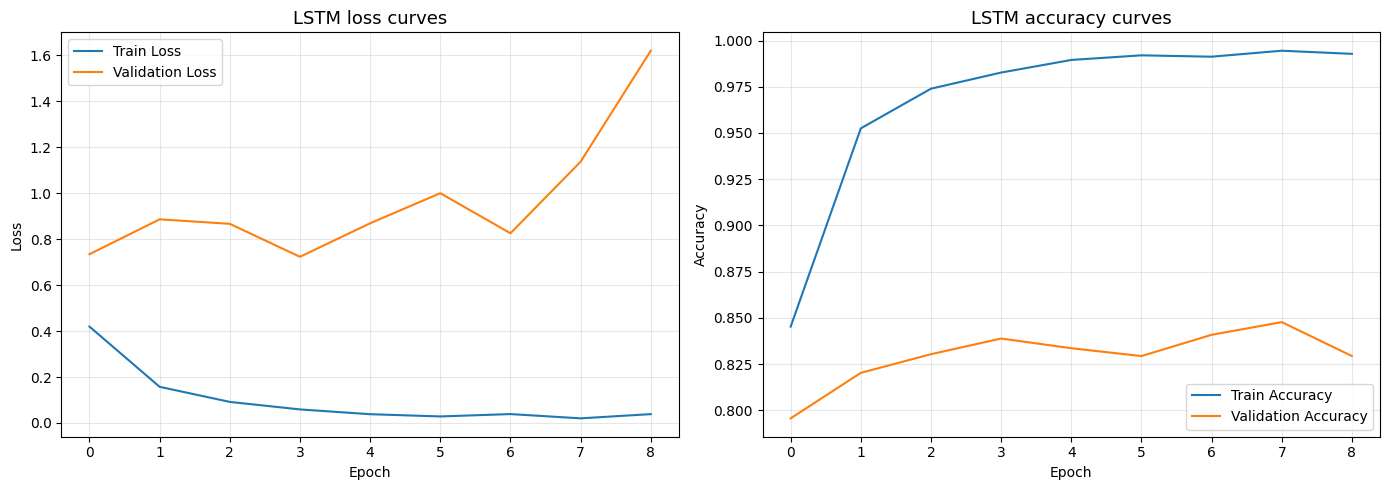

In [47]:
# Plot the train/val loss and accuracy over the epochs
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: loss curves
axes[0].plot(train_losses, label='Train Loss')
axes[0].plot(val_losses,   label='Validation Loss')
axes[0].set_title('LSTM loss curves', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right plot: accuracy curves
axes[1].plot(train_accs, label='Train Accuracy')
axes[1].plot(val_accs,   label='Validation Accuracy')
axes[1].set_title('LSTM accuracy curves', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/lstm_training_curves.png', bbox_inches='tight')
plt.show()

### 9.5 LSTM Evaluation

LSTM classification report:
                    precision    recall  f1-score   support

       Hate Speech     0.4045    0.3112    0.3518       286
Offensive Language     0.8648    0.9453    0.9033      3838
           Neither     0.8137    0.5294    0.6415       833

          accuracy                         0.8388      4957
         macro avg     0.6943    0.5953    0.6322      4957
      weighted avg     0.8297    0.8388    0.8275      4957

Accuracy:  0.8388
Macro F1:  0.6322


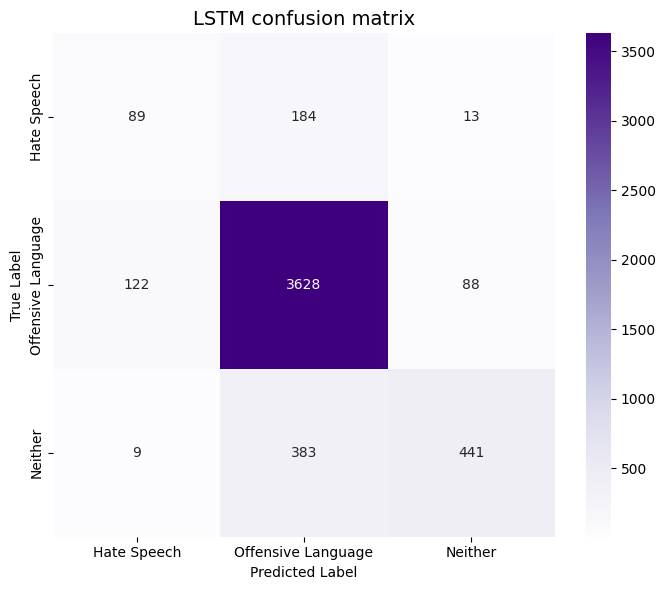

In [49]:
lstm_model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for sequences, labels in test_loader:
        sequences, labels = sequences.to(device), labels.to(device)
        outputs = lstm_model(sequences)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

y_pred_lstm = np.array(all_preds)

lstm_acc = accuracy_score(y_test, y_pred_lstm)
lstm_f1  = f1_score(y_test, y_pred_lstm, average='macro')

print("LSTM classification report:")
print(classification_report(y_test, y_pred_lstm, target_names=class_labels, digits=4))
print(f"Accuracy:  {lstm_acc:.4f}")
print(f"Macro F1:  {lstm_f1:.4f}")

cm_lstm = confusion_matrix(y_test, y_pred_lstm)
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Purples',
            xticklabels=class_labels, yticklabels=class_labels, ax=ax)
ax.set_title('LSTM confusion matrix', fontsize=14)
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('figures/cm_lstm.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Deep Learning Model 2: RoBERTa (Transformer)

### 10.1 Data Preparation for RoBERTa

RoBERTa comes with its own tokeniser, so I don't need to build a vocabulary myself like I did for the LSTM. I just feed it the raw tweets and it does the rest. I wrap everything in a small dataset class so PyTorch can batch it easily.


In [50]:
# Load the tokeniser that matches the 'roberta-base' model.
# The tokeniser knows exactly how RoBERTa was trained to split text into subwords, so we must use the matching one, we can't make up our own.
tokeniser = RobertaTokenizer.from_pretrained('roberta-base')


class TweetTransformerDataset(Dataset):
    """Dataset wrapper that tokenises a tweet on the fly when PyTorch asks for it."""

    def __init__(self, texts, labels, tokeniser, max_len=128):
        # We just store the raw data here — the actual tokenisation happens in __getitem__
        self.texts = texts
        self.labels = labels
        self.tokeniser = tokeniser
        self.max_len = max_len  # maximum number of tokens per tweet

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        # Tokenise a single tweet.
        # - max_length / truncation to cut off anything longer than max_len tokens
        # - padding='max_length' to pad shorter tweets up to max_len with the PAD token
        # - return_tensors='pt' to return PyTorch tensors instead of plain lists
        encoding = self.tokeniser(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        # The encoding comes out with a leading batch dimension of 1, so we squeeze it away.
        # 'attention_mask' tells the model which positions are real tokens (1) and which are padding (0).
        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long)
        }


# Hyperparameters for the transformer input
MAX_LEN_BERT = 128 # longer context than the LSTM, because transformers handle it well
BATCH_SIZE_BERT = 16 # smaller batches because RoBERTa uses a lot more memory

# Build the datasets and dataloaders for RoBERTa.
train_bert_dataset = TweetTransformerDataset(x_train_raw.tolist(), y_train, tokeniser, MAX_LEN_BERT)
test_bert_dataset  = TweetTransformerDataset(x_test_raw.tolist(),  y_test,  tokeniser, MAX_LEN_BERT)

train_bert_loader = DataLoader(train_bert_dataset, batch_size=BATCH_SIZE_BERT, shuffle=True)
test_bert_loader  = DataLoader(test_bert_dataset,  batch_size=BATCH_SIZE_BERT, shuffle=False)

print(f"Training batches: {len(train_bert_loader)}")
print(f"Test batches: {len(test_bert_loader)}")

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Training batches: 2879
Test batches: 310


### 10.2 Fine-tuning RoBERTa

Fine-tuning means I take the pre-trained RoBERTa weights and keep training them on my data for a few more epochs, but with a very small learning rate. Using a small LR is important because the model is already quite good. I also use a linear warmup scheduler for the first 10% of the steps, which is a common trick for transformer fine-tuning.

In [51]:
# Load pre-trained RoBERTa with a fresh 3-way classification head on top
roberta_model = RobertaForSequenceClassification.from_pretrained('roberta-base', num_labels=3).to(device)

# Fine-tuning hyperparameters
EPOCHS_BERT  = 5  # only a few epochs: the model is already well pre-trained
LR_BERT      = 2e-5 # very small LR so we nudge, not wreck, the pre-trained weights
WARMUP_STEPS = int(0.1 * len(train_bert_loader) * EPOCHS_BERT)  # 10% warmup (standard)

optimiser_bert = AdamW(roberta_model.parameters(), lr=LR_BERT, weight_decay=0.01)

# Linear warmup for WARMUP_STEPS, then linear decay to 0 across the remaining steps
scheduler = get_linear_schedule_with_warmup(
    optimiser_bert,
    num_warmup_steps=WARMUP_STEPS,
    num_training_steps=len(train_bert_loader) * EPOCHS_BERT
)

train_losses_bert, val_losses_bert = [], []
train_accs_bert,   val_accs_bert   = [], []

for epoch in range(EPOCHS_BERT):
    # train
    roberta_model.train()
    epoch_loss, correct, total = 0, 0, 0

    for batch_idx, batch in enumerate(train_bert_loader):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)

        optimiser_bert.zero_grad()
        # Passing labels= makes Hugging Face compute the cross-entropy loss for us
        outputs = roberta_model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(roberta_model.parameters(), max_norm=1.0)
        optimiser_bert.step()
        scheduler.step()

        epoch_loss += loss.item()
        _, predicted = torch.max(outputs.logits, 1)
        correct += (predicted == labels).sum().item()
        total   += labels.size(0)

        if (batch_idx + 1) % 100 == 0:
            print(f"  Epoch {epoch+1}, Batch {batch_idx+1}/{len(train_bert_loader)}, Loss: {loss.item():.4f}")

    train_losses_bert.append(epoch_loss / len(train_bert_loader))
    train_accs_bert.append(correct / total)

    # validation
    roberta_model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    all_preds_bert, all_labels_bert = [], []

    with torch.no_grad():
        for batch in test_bert_loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['labels'].to(device)

            outputs = roberta_model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            val_loss += outputs.loss.item()

            _, predicted = torch.max(outputs.logits, 1)
            val_correct += (predicted == labels).sum().item()
            val_total   += labels.size(0)

            all_preds_bert.extend(predicted.cpu().numpy())
            all_labels_bert.extend(labels.cpu().numpy())

    val_losses_bert.append(val_loss / len(test_bert_loader))
    val_accs_bert.append(val_correct / val_total)
    val_f1_bert = f1_score(all_labels_bert, all_preds_bert, average='macro')

    print(f"Epoch {epoch+1}/{EPOCHS_BERT} | "
          f"Train Loss: {train_losses_bert[-1]:.4f} | Train Acc: {train_accs_bert[-1]:.4f} | "
          f"Val Loss: {val_losses_bert[-1]:.4f} | Val Acc: {val_accs_bert[-1]:.4f} | Val F1: {val_f1_bert:.4f}")

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Epoch 1, Batch 100/2879, Loss: 1.1214
  Epoch 1, Batch 200/2879, Loss: 1.0754
  Epoch 1, Batch 300/2879, Loss: 0.7651
  Epoch 1, Batch 400/2879, Loss: 0.6531
  Epoch 1, Batch 500/2879, Loss: 0.5625
  Epoch 1, Batch 600/2879, Loss: 0.3190
  Epoch 1, Batch 700/2879, Loss: 0.3494
  Epoch 1, Batch 800/2879, Loss: 0.4952
  Epoch 1, Batch 900/2879, Loss: 0.3242
  Epoch 1, Batch 1000/2879, Loss: 0.2063
  Epoch 1, Batch 1100/2879, Loss: 0.3496
  Epoch 1, Batch 1200/2879, Loss: 0.5189
  Epoch 1, Batch 1300/2879, Loss: 0.4850
  Epoch 1, Batch 1400/2879, Loss: 0.3531
  Epoch 1, Batch 1500/2879, Loss: 0.2695
  Epoch 1, Batch 1600/2879, Loss: 0.0395
  Epoch 1, Batch 1700/2879, Loss: 0.3861
  Epoch 1, Batch 1800/2879, Loss: 0.1329
  Epoch 1, Batch 1900/2879, Loss: 0.2725
  Epoch 1, Batch 2000/2879, Loss: 0.2669
  Epoch 1, Batch 2100/2879, Loss: 0.1340
  Epoch 1, Batch 2200/2879, Loss: 0.0507
  Epoch 1, Batch 2300/2879, Loss: 1.1933
  Epoch 1, Batch 2400/2879, Loss: 0.1869
  Epoch 1, Batch 2500/287

### 10.3 RoBERTa Training Curves

Same as with the LSTM, I plot the loss and accuracy curves so I can see how training is going and spot any sign of overfitting.

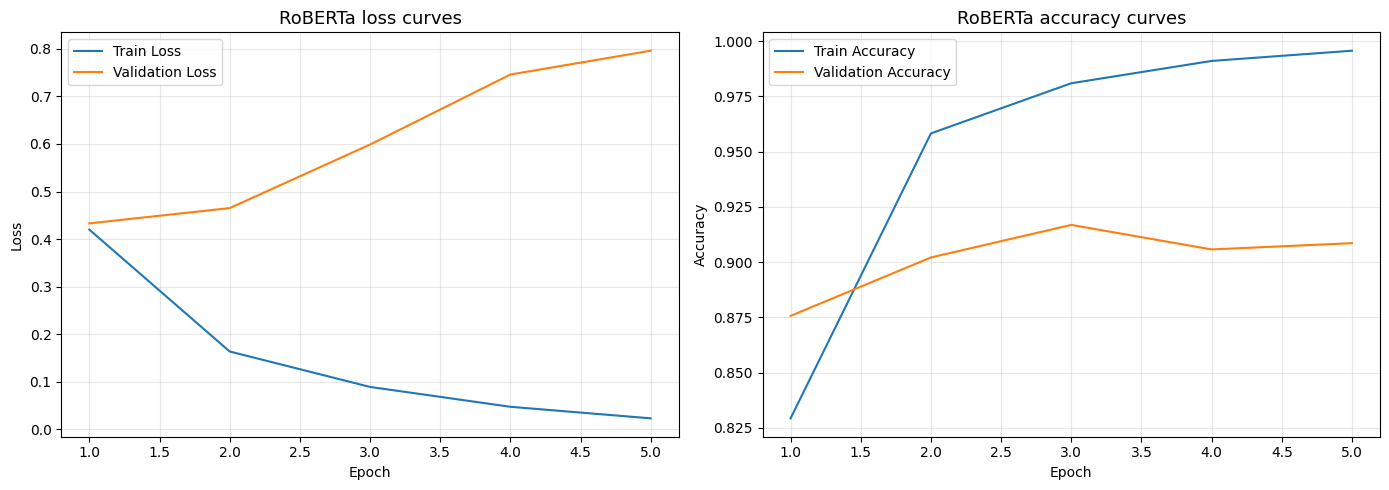

In [52]:
# plot loss and accuracy per epoch for a quick sanity check.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves (train vs val)
axes[0].plot(range(1, len(train_losses_bert)+1), train_losses_bert, label='Train Loss')
axes[0].plot(range(1, len(val_losses_bert)+1),   val_losses_bert,   label='Validation Loss')
axes[0].set_title('RoBERTa loss curves', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy curves (train vs val)
axes[1].plot(range(1, len(train_accs_bert)+1), train_accs_bert, label='Train Accuracy')
axes[1].plot(range(1, len(val_accs_bert)+1),   val_accs_bert,   label='Validation Accuracy')
axes[1].set_title('RoBERTa accuracy curves', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/roberta_training_curves.png', bbox_inches='tight')
plt.show()

### 10.4 RoBERTa Evaluation

And finally, the test-set evaluation for RoBERTa, with the usual classification report, accuracy, macro F1 and confusion matrix.


RoBERTa classification report:
                    precision    recall  f1-score   support

       Hate Speech     0.4774    0.4056    0.4386       286
Offensive Language     0.9345    0.9554    0.9449      3838
           Neither     0.9127    0.8655    0.8885       833

          accuracy                         0.9086      4957
         macro avg     0.7748    0.7422    0.7573      4957
      weighted avg     0.9045    0.9086    0.9062      4957

Accuracy:  0.9086
Macro F1:  0.7573


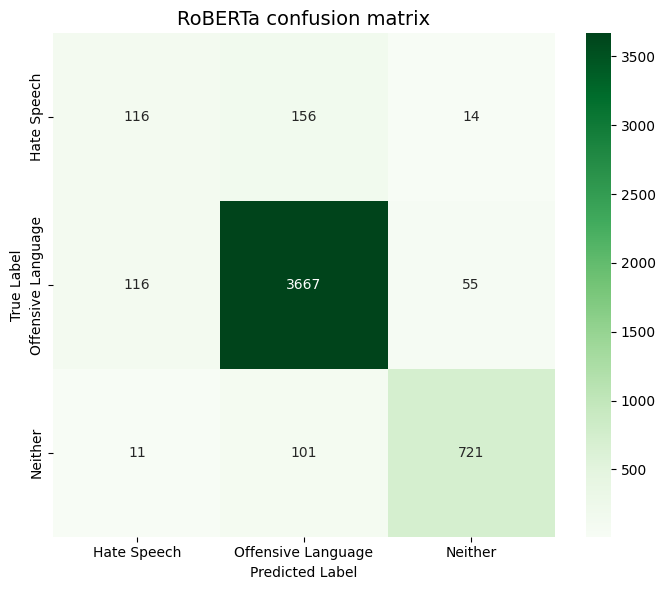

In [53]:
roberta_model.eval()

all_preds_bert, all_labels_bert, all_probs_bert = [], [], []

with torch.no_grad():
    for batch in test_bert_loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)

        outputs = roberta_model(input_ids=input_ids, attention_mask=attention_mask)
        probs = torch.softmax(outputs.logits, dim=1)
        _, predicted = torch.max(outputs.logits, 1)

        all_preds_bert.extend(predicted.cpu().numpy())
        all_labels_bert.extend(labels.cpu().numpy())
        all_probs_bert.extend(probs.cpu().numpy())

y_pred_roberta = np.array(all_preds_bert)

roberta_acc = accuracy_score(y_test, y_pred_roberta)
roberta_f1  = f1_score(y_test, y_pred_roberta, average='macro')

print("RoBERTa classification report:")
print(classification_report(y_test, y_pred_roberta, target_names=class_labels, digits=4))
print(f"Accuracy:  {roberta_acc:.4f}")
print(f"Macro F1:  {roberta_f1:.4f}")

cm_roberta = confusion_matrix(y_test, y_pred_roberta)
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm_roberta, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_labels, yticklabels=class_labels, ax=ax)
ax.set_title('RoBERTa confusion matrix', fontsize=14)
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('figures/cm_roberta.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Results Comparison

In [54]:
# Build a single table that puts every model side by side
results = {
    'Model': ['Logistic Regression', 'SVM', 'LSTM', 'RoBERTa'],
    'Accuracy': [lr_acc, svm_acc, lstm_acc, roberta_acc],
    'Macro F1': [lr_f1, svm_f1, lstm_f1, roberta_f1]
}

# Add one column per class so we can see which models still struggle with hate speech specifically.
for model_name, y_pred in [('LR', y_pred_lr), ('SVM', y_pred_svm),
                           ('LSTM', y_pred_lstm), ('RoBERTa', y_pred_roberta)]:
    per_class = f1_score(y_test, y_pred, average=None)  # F1 per class
    for cls, label in enumerate(class_labels):
        col_name = f'{label} F1'
        results.setdefault(col_name, [])
        results[col_name].append(per_class[cls])

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False, float_format='{:.4f}'.format))

              Model  Accuracy  Macro F1  Hate Speech F1  Offensive Language F1  Neither F1
Logistic Regression    0.8876    0.7228          0.3898                 0.9335      0.8452
                SVM    0.8822    0.6768          0.2851                 0.9302      0.8151
               LSTM    0.8388    0.6322          0.3518                 0.9033      0.6415
            RoBERTa    0.9086    0.7573          0.4386                 0.9449      0.8885


### 11.1 Macro F1 and Accuracy Comparison

Two bar charts: one for accuracy and one for macro F1. Macro F1 is the more honest metric here because it weighs every class equally, so a model that only nails the majority class can't cheat its way to a good score.


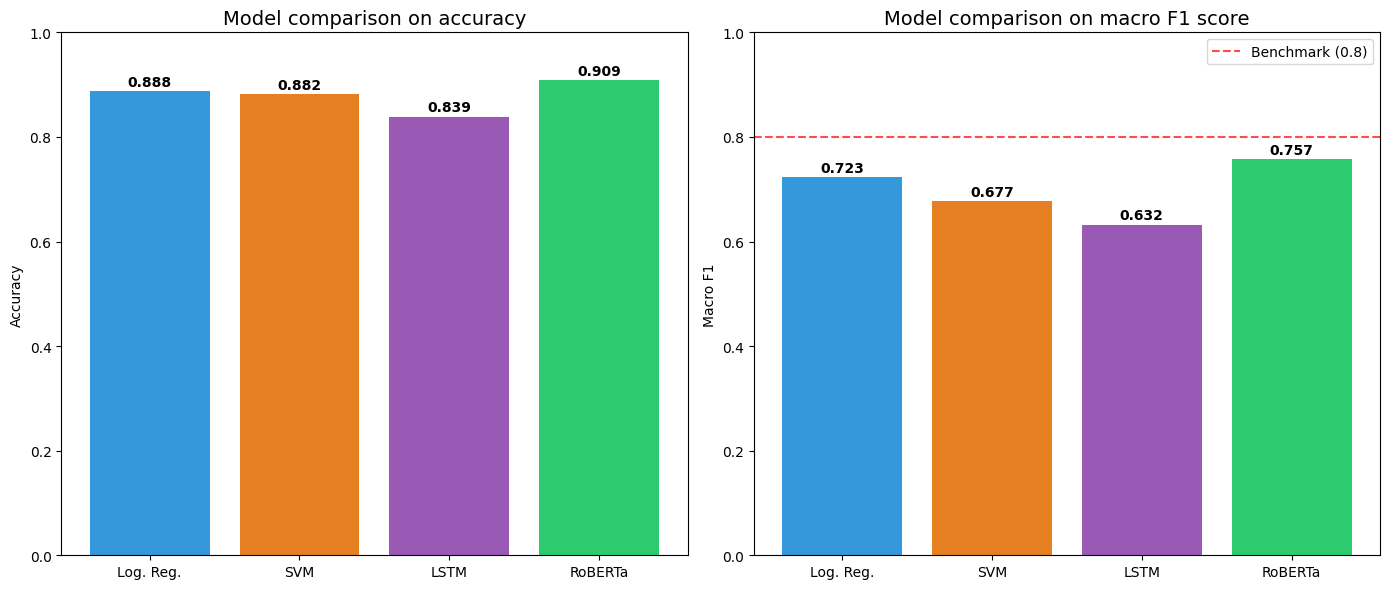

In [55]:
# Side-by-side bar charts comparing every model on accuracy (left) and macro F1 (right)
model_names = ['Log. Reg.', 'SVM', 'LSTM', 'RoBERTa']
accuracies  = [lr_acc, svm_acc, lstm_acc, roberta_acc]
macro_f1s   = [lr_f1, svm_f1, lstm_f1, roberta_f1]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
bar_colours = ['#3498db', '#e67e22', '#9b59b6', '#2ecc71']

# Left plot: accuracy
bars1 = axes[0].bar(model_names, accuracies, color=bar_colours)
axes[0].set_title('Model comparison on accuracy', fontsize=14)
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0, 1)
for bar, val in zip(bars1, accuracies):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                 f'{val:.3f}', ha='center', fontweight='bold')

# Right plot: macro F1 (the metric I really care about on this imbalanced problem)
bars2 = axes[1].bar(model_names, macro_f1s, color=bar_colours)
axes[1].set_title('Model comparison on macro F1 score', fontsize=14)
axes[1].set_ylabel('Macro F1')
axes[1].set_ylim(0, 1)

axes[1].axhline(y=0.8, color='red', linestyle='--', alpha=0.7, label='Benchmark (0.8)')
axes[1].legend()
for bar, val in zip(bars2, macro_f1s):
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                 f'{val:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('figures/model_comparison.png', bbox_inches='tight')
plt.show()

### 11.2 Per-Class F1 Score Comparison

The macro F1 gives a single number but it can hide a lot of detail. To see where each model is actually strong or weak, I also look at the F1 score per class. This makes it clear, for example, whether a model is good overall but still struggles specifically with hate speech.


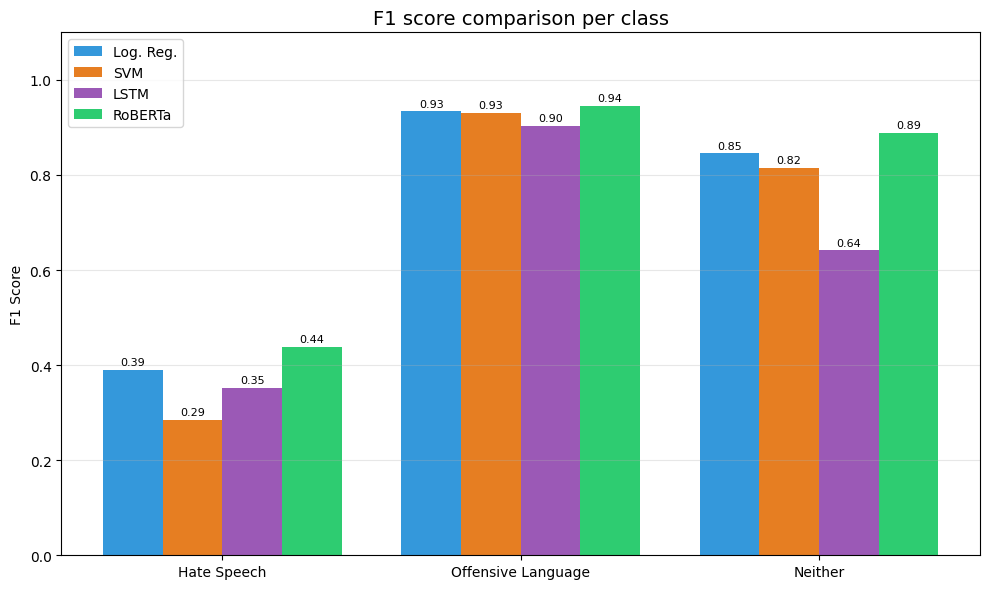

In [56]:
# Grouped bar chart: for each class, show the F1 score of every model next to each other
# This makes it very obvious which model is better at the hard class (hate speech)
per_class_data = {}
for model_name, y_pred in [('Log. Reg.', y_pred_lr), ('SVM', y_pred_svm),
                           ('LSTM', y_pred_lstm), ('RoBERTa', y_pred_roberta)]:
    # average=None gives us [F1_class0, F1_class1, F1_class2]
    per_class_data[model_name] = f1_score(y_test, y_pred, average=None)

# x positions for the 3 classes on the x-axis
x = np.arange(len(class_labels))
width = 0.2  # width of each bar; 4 models * 0.2 = 0.8 total per group

fig, ax = plt.subplots(figsize=(10, 6))
# Loop over the models and offset each group of bars a bit to the right
for i, (model_name, f1s) in enumerate(per_class_data.items()):
    bars = ax.bar(x + i * width, f1s, width, label=model_name,
                  color=['#3498db', '#e67e22', '#9b59b6', '#2ecc71'][i])
    # Write the exact F1 on top of each bar
    for bar, val in zip(bars, f1s):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                f'{val:.2f}', ha='center', fontsize=8)

ax.set_title('F1 score comparison per class', fontsize=14)
ax.set_ylabel('F1 Score')
# Centre the class labels under each group of 4 bars
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(class_labels)
ax.legend()
ax.set_ylim(0, 1.1)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('figures/per_class_f1.png', dpi=150, bbox_inches='tight')
plt.show()

### 11.3 ROC Curves

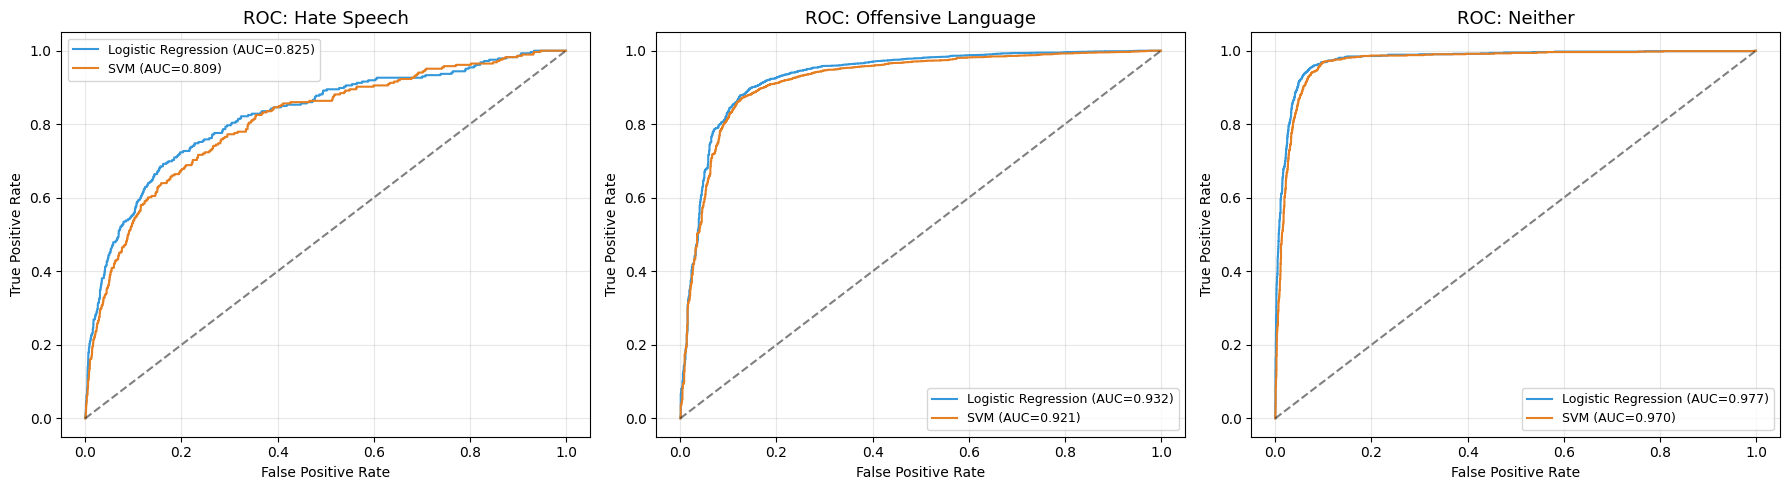

In [57]:
# ROC curves only work for models that can output probabilities.
# Logistic Regression gives them directly; the SVM was calibrated earlier for this reason.

# One-vs-rest binarisation: y_test_bin[:, k] is 1 if the true class is k, 0 otherwise
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Get probability predictions from the two probabilistic models
y_prob_lr  = lr_model.predict_proba(x_test_tfidf)
y_prob_svm = svm_calibrated.predict_proba(x_test_tfidf)

prob_dict = {'Logistic Regression': y_prob_lr,'SVM': y_prob_svm}
colours_roc = ['#3498db', '#e67e22', '#9b59b6', '#2ecc71']

# One subplot per class (hate / offensive / neither)
for cls_idx, cls_name in enumerate(class_labels):
    ax = axes[cls_idx]
    for model_idx, (model_name, y_prob) in enumerate(prob_dict.items()):
        # roc_curve returns FPR and TPR for every possible threshold
        fpr, tpr, _ = roc_curve(y_test_bin[:, cls_idx], y_prob[:, cls_idx])
        # Area Under the Curve
        roc_auc_val = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=colours_roc[model_idx],
                label=f'{model_name} (AUC={roc_auc_val:.3f})')

    # Diagonal dashed line = random classifier, for reference
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)
    ax.set_title(f'ROC: {cls_name}', fontsize=13)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()